# 04 Feature engineering

**Purpose:** turn each planned stop into the inputs the Task 1 models will use, and prove that every input is something a planner actually has when the plan is drafted.

**Inputs:** `stops.parquet` from notebook 03 and the clean reference tables from notebook 02.

**Outputs:**
- `data/processed/task1_features.parquet`: one row per dispatched order (train and test) with all features and, for train, the two labels
- `reports/feature_audit.csv`: every feature, where it comes from and why it is available in time

**The one rule:** Waypoint drafts tomorrow's routes at the 4 PM cutoff. A feature is allowed only if it is known at that moment. That rules out anything measured on the delivery day itself, and even the previous day's results, because those routes may still be on the road at 4 PM.

The feature code lives in `src/xora/features.py` so that notebook 05 and the final notebook build exactly the same inputs. This notebook calls it one group at a time and shows what each group adds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora.io import load_processed, save_processed
from xora.paths import REPORTS
from xora.plotting import apply_style, SERIES, INK
from xora import features as fe

apply_style()
pd.set_option("display.width", 160)

stops = load_processed("stops")
outlets = load_processed("outlets")
vehicles = load_processed("vehicles")
allowance = load_processed("service_allowance")
calendar = load_processed("calendar")
road = load_processed("road_conditions")
traffic = load_processed("traffic_speed")

train = stops.split == "train"
stops.groupby("split").agg(stops=("delivery_id", "size"), first_day=("date", "min"), last_day=("date", "max"))

,stops,first_day,last_day
split,,,
test,5014,2026-02-16,2026-03-28
train,91894,2024-01-01,2026-02-14


The test stops start two days after training ends, and they carry only planned times. The features below are built the same way for both, so the model never sees anything at training time that it would not have for the test.

## 2. Order and vehicle features

What is being delivered, where it goes and what it travels on. All of this is on the order and the drafted plan.

- size of the order: units, weight, volume, and weight per unit (bulky Tech items take longer to move)
- outlet: brand, district, dock type, parking constraint, whether it is a mall with a delivery slot
- vehicle: type, refrigeration and capacity
- `was_deferred`: the order was pushed from the previous day, which the planner knows
- `allowance_min`: today's published allowance for this brand and dock type, the baseline the model has to beat

In [2]:
order_f = fe.order_features(stops, outlets, vehicles, allowance)
print(order_f.shape)
order_f.head(3).T

(96908, 19)


,0,1,2
brand,Fresh,Fresh,Fresh
depot,Peliyagoda,Peliyagoda,Peliyagoda
district,Colombo,Colombo,Colombo
temp_requirement,ambient,ambient,ambient
dock_type,street,street,street
parking_constraint,van_only,van_only,van_only
vehicle_type,van,van,van
vehicle_temp,ambient,ambient,ambient
outlet_id,OUT001,OUT002,OUT003
order_units,8,15,15


## 3. Route position features

Notebook 01 showed that lateness builds up along the route. These features describe where a stop sits in its drafted route and how much room the plan leaves.

- position: stop number, stops before and after, whether the truck comes straight from the same outlet
- load: route volume and weight, and the volume delivered before this stop
- distance and planned travel, for this leg and so far
- timing: planned start, planned arrival, minutes into the route
- window: length, planned slack to closing time, minutes the plan arrives before opening, and the tightest slack still ahead on the route

In [3]:
route_f = fe.route_features(stops)
print(route_f.shape)
route_f.loc[stops.route_id == stops.route_id.iloc[0]].T

(96908, 21)


,0,1,2
seq,0.000,2.000,1.000
is_first_stop,1.000,0.000,0.000
route_n_stops,3.000,3.000,3.000
stops_after,2.000,0.000,1.000
same_outlet_as_previous,0.000,0.000,0.000
route_volume_m3,1.518,1.518,1.518
route_weight_kg,263.300,263.300,263.300
volume_before_m3,0.000,0.954,0.402
route_distance_km,22.100,22.100,22.100
distance_so_far_km,13.700,22.100,18.300


**A check on the plan itself.** The time the plan allows at each stop (the next leg's planned departure minus this arrival) is exactly the published allowance at every stop that has a next leg. So the plan carries no hidden knowledge about service time, and `allowance_min` already captures it. We keep one copy.

In [4]:
s = stops.sort_values(["route_id", "seq"])
planned_stop = s.groupby("route_id").planned_depart_time_min.shift(-1) - s.planned_arrival_time_min_x
has_next = planned_stop.notna()
pd.Series({
    "stops with a next leg": int(has_next.sum()),
    "planned stop time equals the allowance": float((planned_stop[has_next] == order_f.loc[planned_stop[has_next].index, "allowance_min"]).mean()),
})

stops with a next leg                     70329.0
planned stop time equals the allowance        1.0
dtype: float64

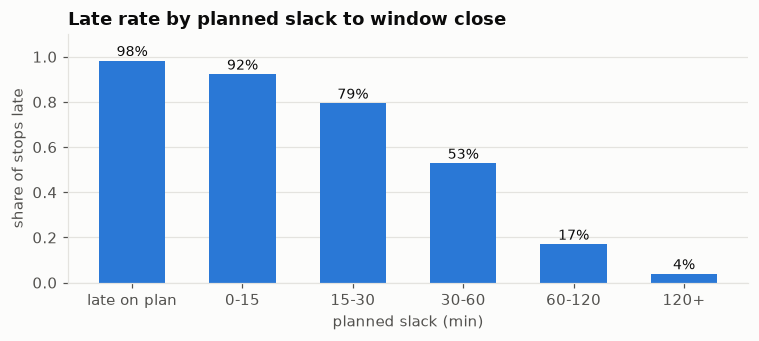

In [5]:
bands = pd.cut(route_f.planned_slack_min, [-np.inf, 0, 15, 30, 60, 120, np.inf],
               labels=["late on plan", "0-15", "15-30", "30-60", "60-120", "120+"])
late_by_band = stops.loc[train].groupby(bands[train], observed=True).late.mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(late_by_band.index.astype(str), late_by_band.values, color=SERIES[0], width=0.6)
for i, v in enumerate(late_by_band.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", color=INK, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title("Late rate by planned slack to window close")
ax.set_xlabel("planned slack (min)")
ax.set_ylabel("share of stops late")
plt.tight_layout()
plt.show()

Planned slack is the single clearest signal for lateness, but even stops with one to two hours of slack are sometimes late. The plan is optimistic, so slack on paper is not slack on the road. Section 6 corrects it with history.

## 4. Calendar and road conditions

- **Calendar:** day of week, month, payday, public holiday, festival day, festival ramp, monsoon, days until the next festival and a trend counter. The calendar is published well ahead.
- **Road advisory:** `disruption_index` for the district and day. The file covers the test dates, so it behaves like a published road and weather advisory. This is the one borderline input, so notebook 05 tests the models with and without it.
- **Typical traffic:** `speed_index` for the district at the planned arrival hour, in or out of monsoon. This is a long-run profile, not a live reading.

Sunday never appears in the data, so a weekend flag would be constant and is left out.

In [6]:
cal_f = fe.calendar_features(stops, calendar)
cond_f = fe.condition_features(stops, route_f, road, traffic)
pd.concat([cal_f, cond_f], axis=1).describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
dow,96908.0,2.52,1.69,0.0,1.0,3.0,4.0,5.0
month,96908.0,6.02,3.57,1.0,3.0,6.0,9.0,12.0
is_payday,96908.0,0.07,0.26,0.0,0.0,0.0,0.0,1.0
is_holiday,96908.0,0.02,0.12,0.0,0.0,0.0,0.0,1.0
monsoon,96908.0,0.48,0.50,0.0,0.0,0.0,1.0,1.0
festival_ramp,96908.0,0.10,0.24,0.0,0.0,0.0,0.0,1.0
is_festival_day,96908.0,0.02,0.12,0.0,0.0,0.0,0.0,1.0
days_to_festival,96908.0,30.81,19.72,0.0,13.0,28.0,49.0,60.0
trend_days,96908.0,408.40,236.82,0.0,204.0,407.0,613.0,817.0
disruption_index,96908.0,92.67,12.82,41.0,91.0,99.0,100.0,100.0


## 5. History features

How an outlet, a vehicle or a district has behaved before is strong evidence, but it is also the easiest place to leak the answer. Three rules keep it honest:

1. **Only finished days count.** A result from day D becomes usable on day D + 2. Plans for D are drafted on D-1, when D-1's own routes may still be running.
2. **Small samples lean on their group.** An outlet's average is blended with its brand and dock type average, weighted by how many past stops it has (smoothing of 20 stops). A new outlet starts at the group average instead of an unreliable guess.
3. **The same code serves train and test.** For a test day, the newest usable history is simply the end of training, which is what a planner would have.

The history features:
- `outlet_hist_service_mean`, `outlet_hist_late_rate`, `outlet_hist_stops`
- `group_hist_service_mean` for the brand and dock type
- `district_hist_travel_ratio`: actual over planned travel time, by district and monsoon
- `vehicle_hist_depart_delay`: how late this vehicle usually leaves the depot

In [7]:
hist_f = fe.history_features(stops)
hist_f.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
group_hist_service_mean,96627.0,18.41,8.66,11.50,16.41,16.86,17.13,88.06
outlet_hist_stops,96908.0,548.05,340.97,0.00,242.00,545.00,849.00,1100.00
outlet_hist_service_mean,96627.0,18.41,10.46,7.96,12.72,15.60,21.05,102.52
outlet_hist_late_rate,96627.0,0.19,0.18,0.00,0.04,0.12,0.29,0.78
district_hist_travel_ratio,96361.0,1.71,0.33,1.05,1.42,1.66,1.92,2.70
vehicle_hist_depart_delay,96636.0,7.82,0.36,6.14,7.60,7.78,8.01,10.79


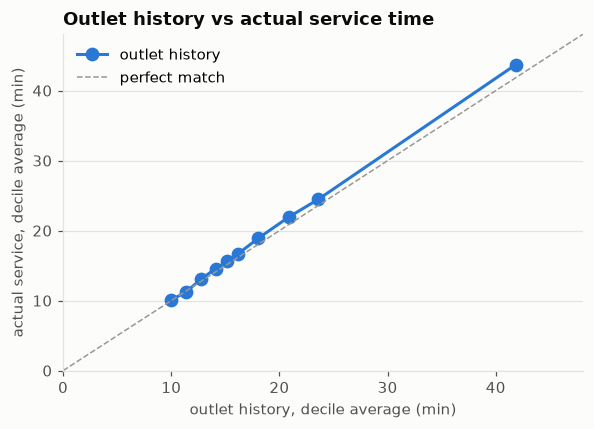

In [8]:
x = hist_f.loc[train, "outlet_hist_service_mean"]
y = stops.loc[train, "service_min"]
deciles = pd.qcut(x, 10, duplicates="drop")
binned = pd.DataFrame({"predicted": x, "actual": y}).groupby(deciles, observed=True).mean()

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(binned.predicted, binned.actual, marker="o", markersize=8, color=SERIES[0], label="outlet history")
lim = [0, binned.max().max() * 1.1]
ax.plot(lim, lim, color="#9a9893", linewidth=1, linestyle="--", label="perfect match")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title("Outlet history vs actual service time")
ax.set_xlabel("outlet history, decile average (min)")
ax.set_ylabel("actual service, decile average (min)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

On its own, an outlet's own past is already a well calibrated guess of its service time: the decile points sit close to the diagonal, slightly above it because service times creep up over time. The model's job is to explain the rest (order size, festivals, paydays, monsoon).

## 6. All features together

`build_task1_features` runs the five groups above and adds four combinations of the plan with history:

- `load_share_volume` and `load_share_weight`: how full the vehicle is
- `expected_travel_min`: planned travel scaled by how much slower that district usually runs
- `slack_after_history_min`: planned slack minus the extra travel history predicts so far on the route, minus the vehicle's usual late departure. This is a realistic version of slack.

In [9]:
feats = fe.build_task1_features(stops, outlets, vehicles, allowance, calendar, road, traffic)
print(feats.shape)
blanks = feats.isna().sum()
blanks[blanks > 0].rename("blank rows").to_frame()

(96908, 61)


,blank rows
group_hist_service_mean,281
outlet_hist_service_mean,281
outlet_hist_late_rate,281
district_hist_travel_ratio,547
vehicle_hist_depart_delay,272
expected_travel_min,547
slack_after_history_min,547


The only blanks are history features in the first days of 2024, before any day has finished. LightGBM handles missing values natively, so these rows stay in.

In [10]:
num = feats.select_dtypes("number")
signal = pd.DataFrame({
    "service_min": num[train].corrwith(stops.loc[train, "service_min"], method="spearman"),
    "late": num[train].corrwith(stops.loc[train, "late"].astype(float), method="spearman"),
}).round(3)
signal.reindex(signal.abs().max(axis=1).sort_values(ascending=False).index).head(15)

,service_min,late
outlet_hist_service_mean,0.672,0.052
slack_after_history_min,-0.038,-0.570
order_volume_m3,0.523,0.041
order_weight_kg,0.511,0.044
planned_slack_min,-0.030,-0.494
outlet_hist_late_rate,0.003,0.447
planned_arrival_min,0.213,0.437
planned_hour,0.215,0.417
speed_index,-0.105,-0.401
minutes_into_route,0.001,0.388


Rank correlations on the training stops are a quick, honest first look (models will find interactions these miss):
- Service time is driven by order size and the outlet's own history.
- Lateness is driven by slack, and the history-corrected slack ranks lateness better than slack on paper. This is the simulation idea in miniature: correct the plan with how the road actually behaves.